# Notebook 10 — Comparación global de modelos

Este notebook consolida los resultados de todos los modelos evaluados en el TFM
sobre la predicción de la huella de carbono operacional del sistema eléctrico
español (2024, resolución horaria, walk-forward con 45 fits, paso 8 días).

**Nota metodológica:** los modelos estadísticos (ARIMA, SARIMA, SARIMAX, AutoReg)
se reentrenan en cada fit del walk-forward con ventana expansiva. Los modelos
neuronales (RNN, LSTM) se evalúan con pesos fijos del entrenamiento inicial —
el reentrenamiento iterativo en CPU es computacionalmente inviable para 45 fits.
Esta asimetría debe tenerse en cuenta al interpretar la comparación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

BASE_DIR    = Path("/home/ubuntu/TFM")
RESULTS_DIR = BASE_DIR / "results"
FIG_DIR     = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("Librerías cargadas OK")
print(f"RESULTS_DIR: {RESULTS_DIR}")

Librerías cargadas OK
RESULTS_DIR: /home/ubuntu/TFM/results


## 1. Carga de resultados

In [2]:
naive_arima_ci  = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")
sarima_ci       = pd.read_csv(RESULTS_DIR / "sarima_ci.csv")
sarimax_ci      = pd.read_csv(RESULTS_DIR / "sarimax_ci.csv")
autoreg_exog_ci = pd.read_csv(RESULTS_DIR / "autoreg_exogenas_ci.csv")
rnn_ci          = pd.read_csv(RESULTS_DIR / "rnn_ci.csv")
lstm_ci         = pd.read_csv(RESULTS_DIR / "lstm_ci.csv")

print("CSVs cargados OK")
print("\nautoreg_exog_ci modelos disponibles:")
print(autoreg_exog_ci["model"].unique())

CSVs cargados OK

autoreg_exog_ci modelos disponibles:
<ArrowStringArray>
[                'B0_base',               'B1_sincos',
                  'B2_ghi',             'B3_ghi_elev',
     'B4_ghi_elev_azimuth',      'B5_sincos_ghi_elev',
          'B6_sincos_week',        'B7_ghi_elev_temp',
 'B8_sincos_ghi_elev_temp',                 'B9_temp',
            'B10_ghi_temp']
Length: 11, dtype: str


In [3]:
# Ajusta estos nombres según lo que imprima la celda anterior
MODELOS_AUTOREG = ["B0_base", "B6_sincos_week", "B9_temperatura"]
autoreg_sel = autoreg_exog_ci[
    autoreg_exog_ci["model"].isin(MODELOS_AUTOREG)
].copy()

all_ci = pd.concat(
    [naive_arima_ci, sarima_ci, sarimax_ci, autoreg_sel, rnn_ci, lstm_ci],
    ignore_index=True
)

print(f"Total modelos: {all_ci['model'].nunique()}")
print(all_ci["model"].unique())

Total modelos: 9
<ArrowStringArray>
[                    'Naive_last',                 'Naive_seasonal',
                 'ARIMA(2, 1, 2)',  'SARIMA(1, 1, 1)x(1, 0, 1, 24)',
 'SARIMAX(1, 1, 1)x(1, 0, 1, 24)',                        'B0_base',
                 'B6_sincos_week',                            'RNN',
          'LSTM(h=128,l=2,lb=7d)']
Length: 9, dtype: str


## 2. Tabla resumen global

In [4]:
rows = []
for model in all_ci["model"].unique():
    row = {"Modelo": model}
    for h in ["48h", "72h"]:
        sub = all_ci[(all_ci["model"] == model) & (all_ci["horizon"] == h)]
        if len(sub) > 0:
            r = sub.iloc[0]
            row[f"MAE_{h}"]  = round(r["MAE_mean"], 2)
            row[f"IC95_{h}"] = f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]"
            row[f"RMSE_{h}"] = round(r["RMSE_mean"], 2)
    rows.append(row)

tabla = pd.DataFrame(rows).sort_values("MAE_48h").reset_index(drop=True)
tabla.insert(0, "Ranking", range(1, len(tabla) + 1))

tabla.to_csv(RESULTS_DIR / "comparacion_global.csv", index=False)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("========== TABLA RESUMEN GLOBAL (ordenada por MAE 48h) ==========\n")
print(tabla.to_string(index=False))

========== TABLA RESUMEN GLOBAL (ordenada por MAE 48h) ==========

 Ranking                         Modelo  MAE_48h       IC95_48h  RMSE_48h  MAE_72h       IC95_72h  RMSE_72h
       1                 B6_sincos_week    17.02 [13.33, 21.62]     20.85    18.81 [14.88, 23.51]     22.95
       2                        B0_base    17.39 [13.58, 22.32]     21.37    18.98 [14.77, 24.02]     23.15
       3          LSTM(h=128,l=2,lb=7d)    20.25 [17.08, 24.42]     24.20    23.52 [19.91, 28.01]     27.76
       4                            RNN    20.68 [17.13, 25.19]     24.71    23.22 [19.60, 27.84]     27.76
       5                 Naive_seasonal    20.84 [16.83, 25.59]     25.78    23.01 [18.37, 28.50]     28.35
       6 SARIMAX(1, 1, 1)x(1, 0, 1, 24)    22.20 [17.91, 27.18]     26.58    26.79 [21.52, 32.98]     31.63
       7  SARIMA(1, 1, 1)x(1, 0, 1, 24)    22.21 [17.93, 27.24]     26.61    26.80 [21.59, 32.94]     31.66
       8                 ARIMA(2, 1, 2)    26.95 [23.49, 30.95]     3

## 3. Visualización comparativa

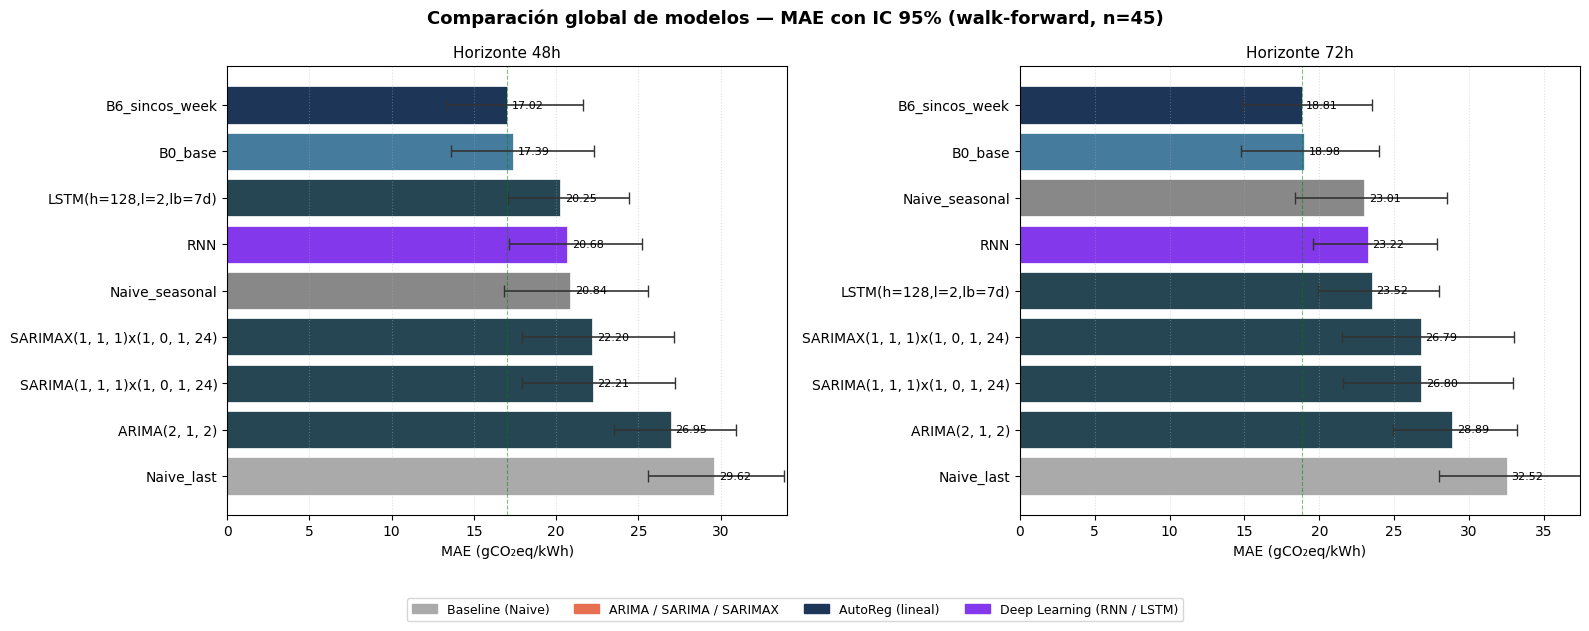

Figura guardada: comparacion_global.png


In [5]:
COLOR_MAP = {
    "Naive_last":                "#aaaaaa",
    "Naive_seasonal":            "#888888",
    "ARIMA(2,1,2)":              "#f4a261",
    "SARIMA(1,1,1)x(1,0,1,24)": "#e76f51",
    "SARIMAX(1,1,1)x(1,0,1,24)":"#e63946",
    "B0_base":                   "#457b9d",
    "B6_sincos_week":            "#1d3557",
    "B9_temperatura":            "#2a9d8f",
    "RNN":                       "#8338ec",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Comparación global de modelos — MAE con IC 95% (walk-forward, n=45)",
    fontsize=13, fontweight="bold"
)

for ax, horizon in zip(axes, ["48h", "72h"]):
    sub = all_ci[all_ci["horizon"] == horizon].copy()
    sub = sub.sort_values("MAE_mean")

    models = sub["model"].tolist()
    mae    = sub["MAE_mean"].tolist()
    ci_lo  = sub["MAE_ci_lo"].tolist()
    ci_hi  = sub["MAE_ci_hi"].tolist()
    colors = [COLOR_MAP.get(m, "#264653") for m in models]
    yerr_lo = [m - lo for m, lo in zip(mae, ci_lo)]
    yerr_hi = [hi - m for m, hi in zip(mae, ci_hi)]

    bars = ax.barh(
        models, mae,
        xerr=[yerr_lo, yerr_hi],
        color=colors, edgecolor="white", linewidth=0.5,
        capsize=4, error_kw={"elinewidth": 1.2, "ecolor": "#333333"}
    )
    for bar, val in zip(bars, mae):
        ax.text(
            val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left", fontsize=8
        )

    ax.set_xlabel("MAE (gCO₂eq/kWh)", fontsize=10)
    ax.set_title(f"Horizonte {horizon}", fontsize=11)
    ax.invert_yaxis()
    ax.axvline(x=min(mae), color="green", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_xlim(0, max(mae) * 1.15)

legend_patches = [
    mpatches.Patch(color="#aaaaaa", label="Baseline (Naive)"),
    mpatches.Patch(color="#e76f51", label="ARIMA / SARIMA / SARIMAX"),
    mpatches.Patch(color="#1d3557", label="AutoReg (lineal)"),
    mpatches.Patch(color="#8338ec", label="Deep Learning (RNN / LSTM)"),
]
fig.legend(
    handles=legend_patches, loc="lower center",
    ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(FIG_DIR / "comparacion_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: comparacion_global.png")

## 5. Conclusiones

El mejor modelo es **AutoReg B6** (lags=336, variables cíclicas sin/cos hora
y día de semana), con MAE 48h = 17.02 gCO₂eq/kWh y MAE 72h = 18.81
gCO₂eq/kWh, lo que supone una mejora del 42% sobre el baseline Naive_last
y del 18% sobre el Naive_seasonal.

**Hallazgos principales:**

1. Los modelos AutoReg lineales superan a todos los demás, incluyendo RNN
   y LSTM. La serie tiene una estructura autorregresiva de corto alcance
   que los modelos lineales capturan eficientemente.

2. Las variables exógenas (radiación solar GHI, elevación solar, temperatura)
   no mejoran significativamente sobre el modelo puramente autorregresivo.
   Solo las variables cíclicas de tiempo (sin/cos hora + día de semana, B6)
   reducen ligeramente el MAE a 48h respecto a B0 (17.02 vs 17.39).

3. SARIMA y SARIMAX obtienen resultados prácticamente idénticos (22.21 vs
   22.20 a 48h), confirmando que las variables solares no aportan información
   adicional a la componente estacional del modelo.

4. El LSTM no supera al Naive_seasonal (20.25 vs 20.84 a 48h). El análisis
   SHAP revela que el modelo concentra su capacidad predictiva en las últimas
   25-30 horas, sin explotar dependencias de largo plazo. Este resultado es
   coherente con la literatura (Makridakis et al., 2018, 2020), que documenta
   que los modelos de deep learning no superan sistemáticamente a los modelos
   estadísticos clásicos en series univariantes con patrones estacionales
   regulares.

5. La asimetría metodológica entre modelos estadísticos (reentrenados en cada
   fit) y modelos neuronales (pesos fijos) puede penalizar parcialmente a RNN
   y LSTM. El reentrenamiento iterativo en CPU es computacionalmente inviable
   para 45 fits.

6. El test set (2025) permanece intacto para la evaluación final del modelo
   seleccionado.

## 6. Referencias

- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2018). Statistical
  and Machine Learning forecasting methods: Concerns and ways forward.
  *PLOS ONE*, 13(3), e0194889. https://doi.org/10.1371/journal.pone.0194889

- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). The M4
  Competition: 100,000 time series and 61 forecasting methods.
  *International Journal of Forecasting*, 36(1), 54–74.
  https://doi.org/10.1016/j.ijforecast.2019.04.014